In [125]:
# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from scipy import stats
import statsmodels.formula.api as smf

COLORS = {
    'hip': '#F4A7B9',
    'spine': '#90C9A0',
}

PHASE_ORDER = [
    'PRE_TEST',
    'IN_TEST',
    'POST_TEST',
    'FOLLOWUP_6MO',
    'FOLLOWUP_1Y'
]

PHASE_LABELS = [
    'Pre',
    'In-Bedrest',
    'Post',
    '6-Month',
    '1-Year'
]

PHASE_POS = {phase: i for i, phase in enumerate(PHASE_ORDER)}

In [142]:
# %%
def load_hip_files(folder='Hip'):
    all_dfs = []

    for fname in os.listdir(folder):

        if not fname.endswith('.csv'):
            continue

        if 'LH_Bone' not in fname and 'RH_Bone' not in fname:
            continue

        fpath = os.path.join(folder, fname)
        df = pd.read_csv(fpath)

        df.columns = df.columns.str.strip()

        # Reconstruct missing follow-up labels from filenames
        if '_6MO_' in fname:
            df['TEST_PHASE'] = df['TEST_PHASE'].fillna('FOLLOWUP_6MO')
            df['BR_DAY'] = df['BR_DAY'].fillna(180)

        if '_1Y_' in fname:
            df['TEST_PHASE'] = df['TEST_PHASE'].fillna('FOLLOWUP_1Y')
            df['BR_DAY'] = df['BR_DAY'].fillna(365)

        side = 'L' if 'LH_Bone' in fname else 'R'
        df['SIDE'] = side

        keep = [
            'SUBJECT',
            'CAMPAIGN',
            'TEST_PHASE',
            'BR_DAY',
            'HTOT_BMD',
            'SIDE'
        ]

        df = df[[c for c in keep if c in df.columns]]
        all_dfs.append(df)

    hip = pd.concat(all_dfs, ignore_index=True)

    hip = hip.dropna(subset=['TEST_PHASE'])

    # Average repeated measurements within each side
    hip = (
        hip.groupby(
            ['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'SIDE'],
            as_index=False
        )
        .agg({'HTOT_BMD': 'mean'})
    )

    # Average left and right hip measurements
    hip = (
        hip.groupby(
            ['SUBJECT', 'TEST_PHASE', 'BR_DAY'],
            as_index=False
        )
        .agg({'HTOT_BMD': 'mean'})
    )

    return hip


hip = load_hip_files()

print(
    f"Hip data loaded: "
    f"{hip['SUBJECT'].nunique()} subjects, "
    f"{len(hip)} records"
)

print(hip['TEST_PHASE'].unique())

Hip data loaded: 32 subjects, 109 records
<StringArray>
['IN_TEST', 'POST_TEST', 'PRE_TEST', 'FOLLOWUP_1Y', 'FOLLOWUP_6MO']
Length: 5, dtype: str


In [158]:
# %%
def load_spine_files(folder='Spine'):
    all_dfs = []

    for fname in os.listdir(folder):

        if not fname.endswith('.csv'):
            continue

        if 'Spine' not in fname or 'S_Bone' in fname:
            continue

        fpath = os.path.join(folder, fname)
        df = pd.read_csv(fpath)

        df.columns = df.columns.str.strip()

        # Reconstruct missing follow-up labels from filenames
        if '_6MO_' in fname:
            df['TEST_PHASE'] = df['TEST_PHASE'].fillna('FOLLOWUP_6MO')
            df['BR_DAY'] = df['BR_DAY'].fillna(180)

        if '_1Y_' in fname:
            df['TEST_PHASE'] = df['TEST_PHASE'].fillna('FOLLOWUP_1Y')
            df['BR_DAY'] = df['BR_DAY'].fillna(365)

        keep = [
            'SUBJECT',
            'CAMPAIGN',
            'TEST_PHASE',
            'BR_DAY',
            'TOT_BMD'
        ]

        df = df[[c for c in keep if c in df.columns]]
        all_dfs.append(df)

    spine = pd.concat(all_dfs, ignore_index=True)

    spine = spine.dropna(subset=['TEST_PHASE'])

    spine = (
        spine.groupby(
            ['SUBJECT', 'TEST_PHASE', 'BR_DAY'],
            as_index=False
        )
        .agg({'TOT_BMD': 'mean'})
    )

    return spine


spine = load_spine_files()

print(
    f"Spine data loaded: "
    f"{spine['SUBJECT'].nunique()} subjects, "
    f"{len(spine)} records"
)

print(spine['TEST_PHASE'].unique())

Spine data loaded: 32 subjects, 109 records
<StringArray>
['IN_TEST', 'POST_TEST', 'PRE_TEST', 'FOLLOWUP_1Y', 'FOLLOWUP_6MO']
Length: 5, dtype: str


In [173]:
# %%
def add_pct_change(df, bmd_col):

    df = df.drop(
        columns=['BASELINE', 'PCT_CHANGE'],
        errors='ignore'
    )

    baseline = (
        df[df['TEST_PHASE'] == 'PRE_TEST']
        .groupby('SUBJECT')[bmd_col]
        .mean()
        .reset_index()
        .rename(columns={bmd_col: 'BASELINE'})
    )

    df = df.merge(
        baseline,
        on='SUBJECT',
        how='left'
    )

    df['PCT_CHANGE'] = (
        (df[bmd_col] - df['BASELINE'])
        / df['BASELINE']
    ) * 100

    return df


hip = add_pct_change(hip, 'HTOT_BMD')
spine = add_pct_change(spine, 'TOT_BMD')

print("Hip:")
print(
    hip[
        ['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'HTOT_BMD', 'BASELINE', 'PCT_CHANGE']
    ].head()
)

print("\nSpine:")
print(
    spine[
        ['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'TOT_BMD', 'BASELINE', 'PCT_CHANGE']
    ].head()
)

Hip:
   SUBJECT TEST_PHASE  BR_DAY  HTOT_BMD  BASELINE  PCT_CHANGE
0      224    IN_TEST    64.0  1.049333  1.075333   -2.417855
1      224  POST_TEST     2.0  1.045500  1.075333   -2.774334
2      224   PRE_TEST     7.0  1.075333  1.075333    0.000000
3      446    IN_TEST    63.0  0.903667  0.916000   -1.346434
4      446  POST_TEST     2.0  0.887167  0.916000   -3.147744

Spine:
   SUBJECT TEST_PHASE  BR_DAY   TOT_BMD  BASELINE  PCT_CHANGE
0    224.0    IN_TEST    64.0  1.003000  1.034333   -3.029326
1    224.0  POST_TEST     2.0  1.001667  1.034333   -3.158234
2    224.0   PRE_TEST     7.0  1.034333  1.034333    0.000000
3    446.0    IN_TEST    63.0  0.997333  0.977667    2.011592
4    446.0  POST_TEST     2.0  1.034000  0.977667    5.762018


In [187]:
# %%
hip_long = hip[
    ['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'HTOT_BMD']
].copy()

hip_long = hip_long.rename(
    columns={'HTOT_BMD': 'BMD'}
)

hip_long['SITE'] = 'Hip'


spine_long = spine[
    ['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'TOT_BMD']
].copy()

spine_long = spine_long.rename(
    columns={'TOT_BMD': 'BMD'}
)

spine_long['SITE'] = 'Spine'


combined = pd.concat(
    [hip_long, spine_long],
    ignore_index=True
)

combined = combined.dropna(subset=['BMD'])

combined['TEST_PHASE'] = pd.Categorical(
    combined['TEST_PHASE'],
    categories=PHASE_ORDER,
    ordered=True
)

combined['SITE'] = pd.Categorical(
    combined['SITE'],
    categories=['Hip', 'Spine']
)

print(f"Total observations: {len(combined)}")

print(
    combined
    .groupby(['SITE', 'TEST_PHASE'], observed=True)
    .size()
)

Total observations: 218
SITE   TEST_PHASE  
Hip    PRE_TEST        32
       IN_TEST         15
       POST_TEST       27
       FOLLOWUP_6MO    17
       FOLLOWUP_1Y     18
Spine  PRE_TEST        32
       IN_TEST         15
       POST_TEST       27
       FOLLOWUP_6MO    17
       FOLLOWUP_1Y     18
dtype: int64


In [223]:
# %%
def paired_cohens_dz(df, bmd_col):
    """
    Paired Cohen's dz for PRE_TEST vs POST_TEST.

    Positive values indicate a decrease from pre-bedrest
    to post-bedrest.
    """

    pre = (
        df[df['TEST_PHASE'] == 'PRE_TEST']
        [['SUBJECT', bmd_col]]
        .rename(columns={bmd_col: 'PRE'})
    )

    post = (
        df[df['TEST_PHASE'] == 'POST_TEST']
        [['SUBJECT', bmd_col]]
        .rename(columns={bmd_col: 'POST'})
    )

    paired = pre.merge(
        post,
        on='SUBJECT',
        how='inner'
    ).dropna()

    differences = paired['PRE'] - paired['POST']

    dz = (
        differences.mean()
        / differences.std(ddof=1)
    )

    return dz, len(paired)


effect_rows = []

for site_name, df, bmd_col in [
    ('Hip', hip, 'HTOT_BMD'),
    ('Spine', spine, 'TOT_BMD')
]:

    dz, n = paired_cohens_dz(
        df,
        bmd_col
    )

    effect_rows.append({
        'Site': site_name,
        'Comparison': 'Pre vs Post',
        'Cohens_dz': dz,
        'Paired_n': n
    })

effect_sizes = pd.DataFrame(effect_rows)

print(effect_sizes.round(3))

effect_sizes.to_csv(
    'effect_sizes.csv',
    index=False
)

    Site   Comparison  Cohens_dz  Paired_n
0    Hip  Pre vs Post      1.880        27
1  Spine  Pre vs Post      0.311        27


In [224]:
# %%
model = smf.mixedlm(
    "BMD ~ C(TEST_PHASE, Treatment(reference='PRE_TEST')) * SITE",
    data=combined,
    groups=combined["SUBJECT"]
)

result = model.fit(
    method='lbfgs',
    reml=True
)

print(result.summary())

                                         Mixed Linear Model Regression Results
Model:                                   MixedLM                      Dependent Variable:                      BMD     
No. Observations:                        218                          Method:                                  REML    
No. Groups:                              32                           Scale:                                   0.0022  
Min. group size:                         2                            Log-Likelihood:                          287.1226
Max. group size:                         10                           Converged:                               Yes     
Mean group size:                         6.8                                                                           
-----------------------------------------------------------------------------------------------------------------------
                                                                             Coef

/Users/mariambashir/market-intelligence-system/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [225]:
# %%
conf_int = result.conf_int()

summary_table = pd.DataFrame({
    'Coefficient': result.params,
    'Std_Error': result.bse,
    'p_value': result.pvalues,
})

summary_table['CI_lower_95'] = conf_int[0]
summary_table['CI_upper_95'] = conf_int[1]

summary_table = summary_table.round(4)

print(summary_table)

summary_table.to_csv(
    'mixed_model_results.csv'
)

print("\nSaved to mixed_model_results.csv")

                                                    Coefficient  Std_Error  \
Intercept                                                1.0066     0.0145   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...      -0.0318     0.0150   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...      -0.0264     0.0123   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...       0.0013     0.0144   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...       0.0036     0.0141   
SITE[T.Spine]                                            0.0156     0.0116   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...       0.0304     0.0206   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...       0.0224     0.0172   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...      -0.0111     0.0197   
C(TEST_PHASE, Treatment(reference='PRE_TEST'))[...      -0.0110     0.0194   
Group Var                                                2.0998     0.6221   

                                                    p_value  CI

In [226]:
# Build a subject x phase presence matrix (1 = data present, 0 = missing)
phase_order = ['PRE_TEST', 'IN_TEST', 'POST_TEST', 'FOLLOWUP_6MO', 'FOLLOWUP_1Y']

hip_presence = (
    hip.pivot_table(index='SUBJECT', columns='TEST_PHASE', values='HTOT_BMD', aggfunc='count')
    .reindex(columns=phase_order)
    .notna()
    .astype(int)
)

print("Missingness pattern (1 = present, 0 = missing), Hip:")
print(hip_presence)

print("\nTotal subjects with data at each phase:")
print(hip_presence.sum())

print("\nSubjects missing at least one follow-up (6MO or 1Y):")
missing_followup = hip_presence[(hip_presence['FOLLOWUP_6MO'] == 0) | (hip_presence['FOLLOWUP_1Y'] == 0)]
print(f"{len(missing_followup)} out of {len(hip_presence)} subjects")

Missingness pattern (1 = present, 0 = missing), Hip:
TEST_PHASE  PRE_TEST  IN_TEST  POST_TEST  FOLLOWUP_6MO  FOLLOWUP_1Y
SUBJECT                                                            
224                1        1          1             0            0
446                1        1          1             0            0
992                1        1          1             0            0
3768               1        0          1             0            0
3985               1        1          1             0            1
4023               1        0          1             0            0
5165               1        1          1             1            1
5580               1        0          1             1            1
5683               1        0          0             0            0
5705               1        0          0             1            1
5788               1        1          1             0            0
5814               1        0          1             1         

In [252]:
# %%
campaign_map = {}

for fname in os.listdir('Hip'):

    if not fname.endswith('.csv'):
        continue

    if fname == '.DS_Store':
        continue

    parts = fname.split('_')

    if len(parts) <= 5:
        continue

    campaign_code = parts[4]
    subject_id = parts[5]

    if subject_id == 'All':
        continue

    campaign_map[subject_id] = campaign_code


campaign_df = pd.DataFrame(
    list(campaign_map.items()),
    columns=['SUBJECT', 'CAMPAIGN_CODE']
)

campaign_df['SUBJECT'] = pd.to_numeric(
    campaign_df['SUBJECT'],
    errors='coerce'
)

campaign_df = campaign_df.dropna(
    subset=['SUBJECT']
)

campaign_df['SUBJECT'] = campaign_df['SUBJECT'].astype(int)

merged = (
    hip_presence
    .reset_index()
    .merge(campaign_df, on='SUBJECT')
)

print(
    merged[
        ['SUBJECT', 'CAMPAIGN_CODE', 'IN_TEST']
    ].sort_values('CAMPAIGN_CODE')
)

print("\nIN_TEST presence by campaign:")

print(
    merged
    .groupby('CAMPAIGN_CODE')['IN_TEST']
    .agg(['sum', 'count'])
)

    SUBJECT CAMPAIGN_CODE  IN_TEST
10     7772           C3C        1
9      7352           C3C        1
0      3985           C3D        1
16     8881           C3D        1
15     8779           C3D        1
14     8615           C3D        1
12     7984           C3D        1
11     7961           C3D        1
1      5165           C3D        1
7      6043           C3E        1
22     9846           C3F        0
4      5705           C3F        0
13     8454           C3F        0
3      5683           C3F        0
17     9016           C3F        1
23     9947           C3F        0
8      6858           C3G        0
5      5814           C3G        0
2      5580           C3G        0
18     9032           C3G        0
19     9139           C3G        0
20     9314           C3G        0
21     9485           C3G        0
6      5907           C3H        0

IN_TEST presence by campaign:
               sum  count
CAMPAIGN_CODE            
C3C              2      2
C3D             

In [253]:
# %%
hip_presence = (
    hip.pivot_table(
        index='SUBJECT',
        columns='TEST_PHASE',
        values='HTOT_BMD',
        aggfunc='count'
    )
    .reindex(columns=PHASE_ORDER)
    .notna()
    .astype(int)
)


spine_presence = (
    spine.pivot_table(
        index='SUBJECT',
        columns='TEST_PHASE',
        values='TOT_BMD',
        aggfunc='count'
    )
    .reindex(columns=PHASE_ORDER)
    .notna()
    .astype(int)
)

# Make sure both matrices contain the same subjects
all_subjects = sorted(
    set(hip_presence.index) | set(spine_presence.index)
)

hip_presence = hip_presence.reindex(
    index=all_subjects,
    fill_value=0
)

spine_presence = spine_presence.reindex(
    index=all_subjects,
    fill_value=0
)

# Verify that hip and spine have identical availability
missingness_matches = hip_presence.equals(spine_presence)

print(
    f"Hip and spine missingness patterns identical: "
    f"{missingness_matches}"
)

if not missingness_matches:
    print("WARNING: Hip and spine availability differ.")
else:
    print(
        "The hip missingness matrix is therefore used as the "
        "representative Hip & Spine availability figure."
    )

print("\nTotal subjects with data at each phase:")
print(hip_presence.sum())

missing_followup = hip_presence[
    (hip_presence['FOLLOWUP_6MO'] == 0) |
    (hip_presence['FOLLOWUP_1Y'] == 0)
]

print(
    f"\nSubjects missing at least one follow-up: "
    f"{len(missing_followup)} / {len(hip_presence)}"
)

Hip and spine missingness patterns identical: True
The hip missingness matrix is therefore used as the representative Hip & Spine availability figure.

Total subjects with data at each phase:
TEST_PHASE
PRE_TEST        32
IN_TEST         15
POST_TEST       26
FOLLOWUP_6MO    17
FOLLOWUP_1Y     18
dtype: int64

Subjects missing at least one follow-up: 17 / 32


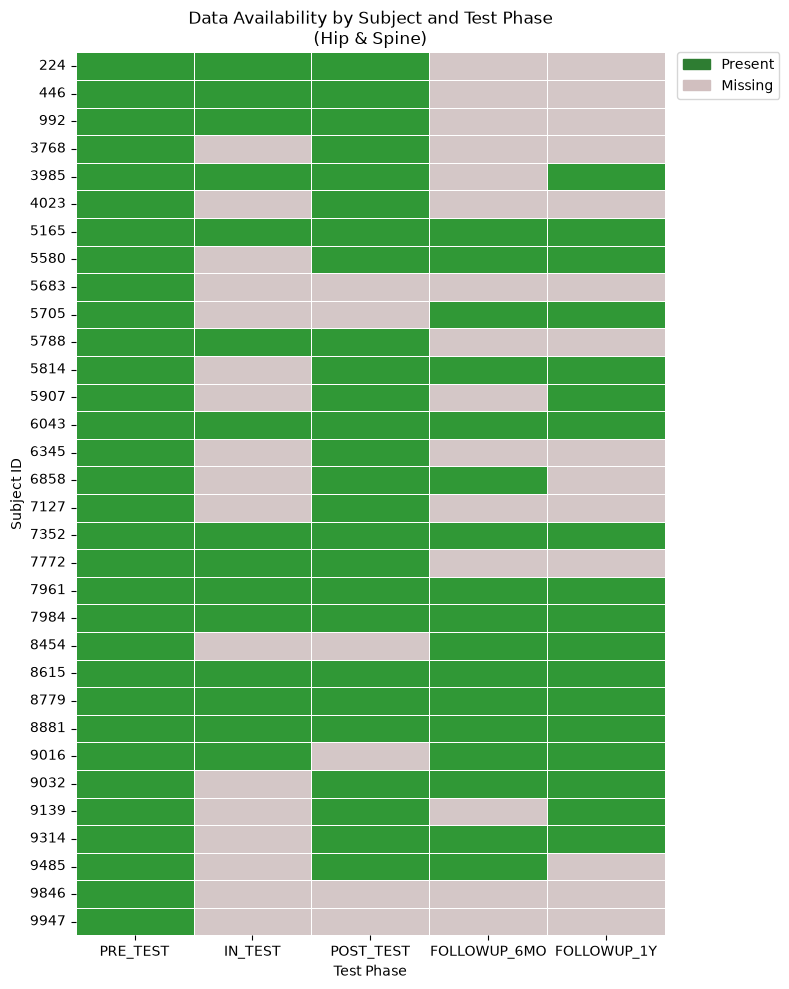

In [254]:
# %%
fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    hip_presence,
    cmap=["#D4C7C7", "#309836"],
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title(
    'Data Availability by Subject and Test Phase\n(Hip & Spine)',
    fontsize=12
)

ax.set_xlabel('Test Phase')
ax.set_ylabel('Subject ID')

present_patch = mpatches.Patch(
    color='#2E7D32',
    label='Present'
)

missing_patch = mpatches.Patch(
    color='#D1BFBF',
    label='Missing'
)

ax.legend(
    handles=[present_patch, missing_patch],
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()

plt.savefig(
    'figure_missingness.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [255]:
def add_pct_change(df, bmd_col):
    df = df.drop(columns=['BASELINE', 'PCT_CHANGE'], errors='ignore')
    baseline = (
        df[df['TEST_PHASE'] == 'PRE_TEST']
        .groupby('SUBJECT')[bmd_col]
        .mean()
        .reset_index()
        .rename(columns={bmd_col: 'BASELINE'})
    )
    df = df.merge(baseline, on='SUBJECT', how='left')
    df['PCT_CHANGE'] = ((df[bmd_col] - df['BASELINE']) / df['BASELINE']) * 100
    return df

hip = add_pct_change(hip, 'HTOT_BMD')
spine = add_pct_change(spine, 'TOT_BMD')
print(hip.columns.tolist())
print(spine.columns.tolist())

['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'HTOT_BMD', 'BASELINE', 'PCT_CHANGE']
['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'TOT_BMD', 'BASELINE', 'PCT_CHANGE']


In [256]:
print(hip.columns.tolist())

['SUBJECT', 'TEST_PHASE', 'BR_DAY', 'HTOT_BMD', 'BASELINE', 'PCT_CHANGE']


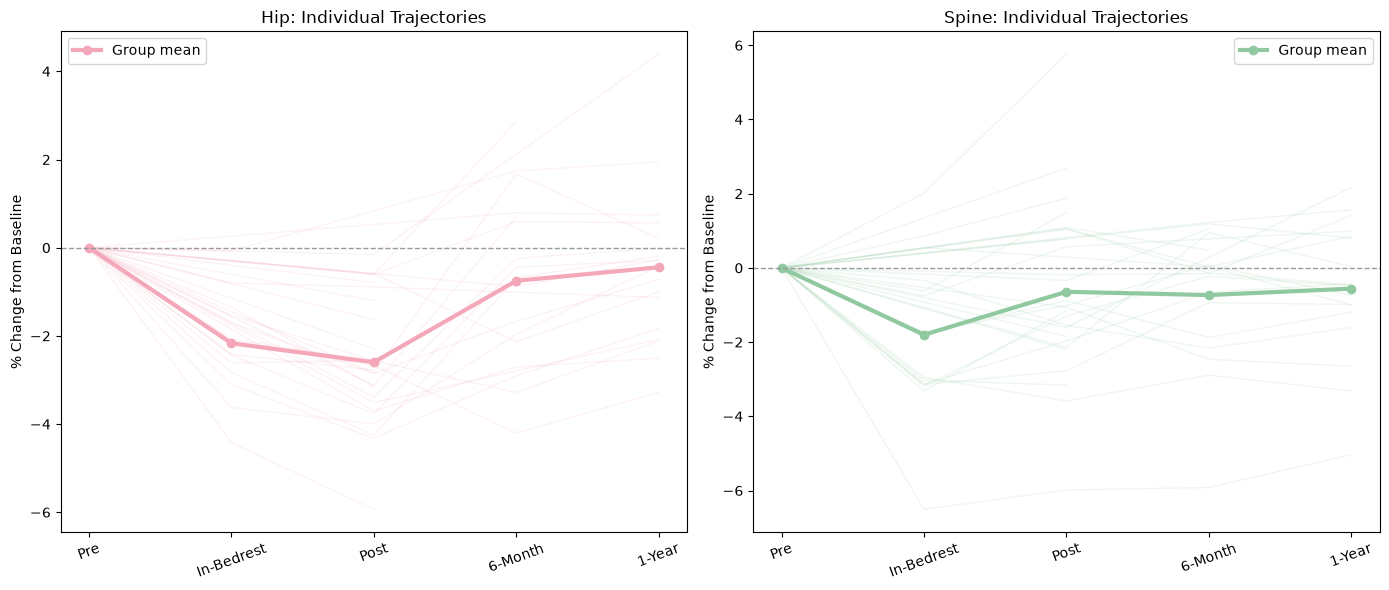

In [262]:
# %%
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

for ax, df, label, color in [
    (axes[0], hip, 'Hip', COLORS['hip']),
    (axes[1], spine, 'Spine', COLORS['spine'])
]:

    df_plot = df[
        df['TEST_PHASE'].isin(PHASE_ORDER)
    ].copy()

    df_plot['X'] = (
        df_plot['TEST_PHASE']
        .map(PHASE_POS)
    )

    # Individual participant trajectories
    for subj, sub_df in df_plot.groupby('SUBJECT'):

        sub_df = sub_df.sort_values('X')

        ax.plot(
            sub_df['X'],
            sub_df['PCT_CHANGE'],
            color=color,
            alpha=0.15,
            linewidth=1
        )

    # Group mean
    group_mean = (
        df_plot
        .groupby('X')['PCT_CHANGE']
        .mean()
    )

    ax.plot(
        group_mean.index,
        group_mean.values,
        color=color,
        linewidth=3,
        marker='o',
        markersize=6,
        label='Group mean'
    )

    ax.axhline(
        0,
        color='#999999',
        linewidth=1,
        linestyle='--'
    )

    ax.set_xticks(
        range(len(PHASE_ORDER))
    )

    ax.set_xticklabels(
        PHASE_LABELS,
        rotation=20
    )

    ax.set_ylabel(
        '% Change from Baseline'
    )

    ax.set_title(
        f'{label}: Individual Trajectories'
    )

    ax.legend()


plt.tight_layout()

plt.savefig(
    'figure_trajectories.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [267]:
# %%
# Build model-based estimates for each site and phase

fixed_effects = result.fe_params
cov_fixed = result.cov_params().loc[
    fixed_effects.index,
    fixed_effects.index
]


def get_design_vector(site, phase):
    """
    Create the fixed-effect design vector corresponding
    to one site/phase combination.
    """

    row = pd.DataFrame({
        'TEST_PHASE': pd.Categorical(
            [phase],
            categories=PHASE_ORDER,
            ordered=True
        ),
        'SITE': pd.Categorical(
            [site],
            categories=['Hip', 'Spine']
        )
    })

    # Use the same formula structure as the fitted model
    from patsy import build_design_matrices

    design_info = result.model.data.design_info

    X = build_design_matrices(
        [design_info],
        row,
        return_type='dataframe'
    )[0]

    return X.iloc[0].reindex(
        fixed_effects.index,
        fill_value=0
    ).values


rows = []

for site in ['Hip', 'Spine']:

    # Baseline model estimate
    x_baseline = get_design_vector(
        site,
        'PRE_TEST'
    )

    baseline_mean = np.dot(
        x_baseline,
        fixed_effects.values
    )

    for phase in PHASE_ORDER:

        x_phase = get_design_vector(
            site,
            phase
        )

        phase_mean = np.dot(
            x_phase,
            fixed_effects.values
        )

        # Difference from baseline
        x_diff = x_phase - x_baseline

        change = np.dot(
            x_diff,
            fixed_effects.values
        )

        # Standard error of the contrast
        variance = np.dot(
            x_diff,
            np.dot(cov_fixed, x_diff)
        )

        se = np.sqrt(
            max(variance, 0)
        )

        ci_lower_change = change - 1.96 * se
        ci_upper_change = change + 1.96 * se

        # Convert absolute change to percentage of baseline
        pct_change = (
            change / baseline_mean
        ) * 100

        pct_ci_lower = (
            ci_lower_change / baseline_mean
        ) * 100

        pct_ci_upper = (
            ci_upper_change / baseline_mean
        ) * 100

        rows.append({
            'SITE': site,
            'TEST_PHASE': phase,
            'BASELINE_BMD': baseline_mean,
            'MODEL_BMD': phase_mean,
            'CHANGE_BMD': change,
            'CI_lower_BMD': ci_lower_change,
            'CI_upper_BMD': ci_upper_change,
            'PCT_CHANGE': pct_change,
            'CI_lower_pct': pct_ci_lower,
            'CI_upper_pct': pct_ci_upper
        })


model_change_df = pd.DataFrame(rows)

print(
    model_change_df.round(4)
)

    SITE    TEST_PHASE  BASELINE_BMD  MODEL_BMD  CHANGE_BMD  CI_lower_BMD  \
0    Hip      PRE_TEST        1.0066     1.0066      0.0000        0.0000   
1    Hip       IN_TEST        1.0066     0.9748     -0.0318       -0.0612   
2    Hip     POST_TEST        1.0066     0.9802     -0.0264       -0.0505   
3    Hip  FOLLOWUP_6MO        1.0066     1.0079      0.0013       -0.0269   
4    Hip   FOLLOWUP_1Y        1.0066     1.0102      0.0036       -0.0240   
5  Spine      PRE_TEST        1.0222     1.0222      0.0000        0.0000   
6  Spine       IN_TEST        1.0222     1.0209     -0.0014       -0.0308   
7  Spine     POST_TEST        1.0222     1.0183     -0.0039       -0.0281   
8  Spine  FOLLOWUP_6MO        1.0222     1.0124     -0.0098       -0.0380   
9  Spine   FOLLOWUP_1Y        1.0222     1.0148     -0.0074       -0.0350   

   CI_upper_BMD  PCT_CHANGE  CI_lower_pct  CI_upper_pct  
0        0.0000      0.0000        0.0000        0.0000  
1       -0.0023     -3.1547       -6

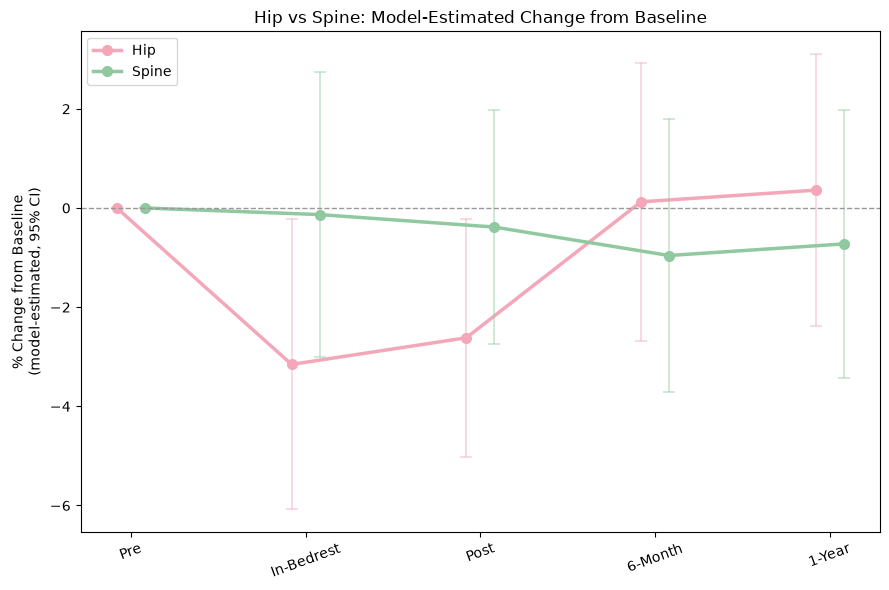

In [272]:
# %%
fig, ax = plt.subplots(
    figsize=(9, 6)
)

offset = 0.08

for site, color, shift in [
    ('Hip', COLORS['hip'], -offset),
    ('Spine', COLORS['spine'], offset)
]:

    site_data = model_change_df[
        model_change_df['SITE'] == site
    ].copy()

    site_data['X'] = (
        site_data['TEST_PHASE']
        .map(PHASE_POS)
        + shift
    )

    site_data = site_data.sort_values('X')

    yerr = [
        site_data['PCT_CHANGE']
        - site_data['CI_lower_pct'],

        site_data['CI_upper_pct']
        - site_data['PCT_CHANGE']
    ]

    ax.errorbar(
        site_data['X'],
        site_data['PCT_CHANGE'],
        yerr=yerr,
        fmt='none',
        ecolor=color,
        elinewidth=1.2,
        alpha=0.5,
        capsize=4,
        capthick=1.2
    )

    ax.plot(
        site_data['X'],
        site_data['PCT_CHANGE'],
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=7,
        label=site
    )


ax.axhline(
    0,
    color='#999999',
    linewidth=1,
    linestyle='--'
)

ax.set_ylabel(
    '% Change from Baseline\n(model-estimated, 95% CI)'
)

ax.set_title(
    'Hip vs Spine: Model-Estimated Change from Baseline'
)

ax.set_xticks(
    range(len(PHASE_ORDER))
)

ax.set_xticklabels(
    PHASE_LABELS,
    rotation=20
)

ax.legend()

plt.tight_layout()

plt.savefig(
    'figure_hip_vs_spine_model.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [277]:
# %%
model_change_df.to_csv(
    'model_estimated_changes.csv',
    index=False
)

print(
    "Saved model_estimated_changes.csv"
)

Saved model_estimated_changes.csv


In [282]:
# %%
final_results = model_change_df[
    [
        'SITE',
        'TEST_PHASE',
        'PCT_CHANGE',
        'CI_lower_pct',
        'CI_upper_pct'
    ]
].copy()

final_results = final_results.rename(
    columns={
        'TEST_PHASE': 'Phase',
        'PCT_CHANGE': 'Estimated % Change',
        'CI_lower_pct': '95% CI Lower',
        'CI_upper_pct': '95% CI Upper'
    }
)

final_results = final_results.round(2)

print(final_results)

final_results.to_csv(
    'final_model_results.csv',
    index=False
)

    SITE         Phase  Estimated % Change  95% CI Lower  95% CI Upper
0    Hip      PRE_TEST                0.00          0.00          0.00
1    Hip       IN_TEST               -3.15         -6.08         -0.23
2    Hip     POST_TEST               -2.62         -5.02         -0.22
3    Hip  FOLLOWUP_6MO                0.12         -2.67          2.92
4    Hip   FOLLOWUP_1Y                0.36         -2.38          3.10
5  Spine      PRE_TEST                0.00          0.00          0.00
6  Spine       IN_TEST               -0.13         -3.01          2.75
7  Spine     POST_TEST               -0.38         -2.75          1.98
8  Spine  FOLLOWUP_6MO               -0.96         -3.72          1.80
9  Spine   FOLLOWUP_1Y               -0.72         -3.43          1.98


In [286]:
print(results_table.to_markdown())

|                                                                              |   Coefficient |   Std_Err |   p_value |   CI_lower_95 |   CI_upper_95 |
|:-----------------------------------------------------------------------------|--------------:|----------:|----------:|--------------:|--------------:|
| Intercept                                                                    |        1.0066 |    0.0145 |    0      |        0.9782 |        1.035  |
| C(TEST_PHASE, Treatment(reference='PRE_TEST'))[T.IN_TEST]                    |       -0.0318 |    0.015  |    0.0344 |       -0.0612 |       -0.0023 |
| C(TEST_PHASE, Treatment(reference='PRE_TEST'))[T.POST_TEST]                  |       -0.0264 |    0.0123 |    0.0325 |       -0.0505 |       -0.0022 |
| C(TEST_PHASE, Treatment(reference='PRE_TEST'))[T.FOLLOWUP_6MO]               |        0.0013 |    0.0144 |    0.9306 |       -0.0269 |        0.0294 |
| C(TEST_PHASE, Treatment(reference='PRE_TEST'))[T.FOLLOWUP_1Y]                |  